In [48]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


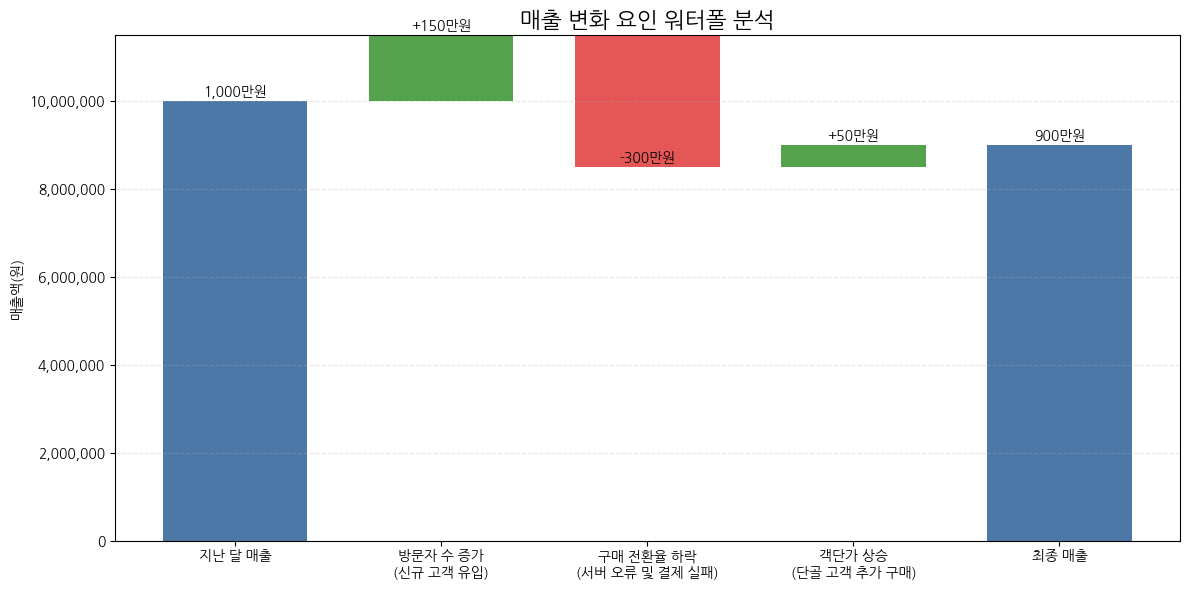


매출 변화 분석 결과
지난 달 매출 : 10,000,000원
방문자 수 증가 : +1,500,000원
구매 전환율 하락 : -3,000,000원
객단가 상승 : +500,000원
------------------------------
최종 매출 : 9,000,000원


In [58]:
# ==========================================================
# 워터폴 차트 : 매출 변화 요인 분석
# Google Colab
# ==========================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ----------------------------------------------------------
# 한글 폰트
# ----------------------------------------------------------
!apt-get -qq install fonts-nanum > /dev/null

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------------
# 데이터
# ----------------------------------------------------------

start_sales = 10000000  # 지난 달 매출

changes = [
    1500000,   # 방문자 수 증가
   -3000000,   # 구매 전환율 하락
     500000    # 객단가 상승
]

labels = [
    '지난 달 매출',
    '방문자 수 증가\n(신규 고객 유입)',
    '구매 전환율 하락\n(서버 오류 및 결제 실패)',
    '객단가 상승\n(단골 고객 추가 구매)',
    '최종 매출'
]

# ----------------------------------------------------------
# 누적 계산
# ----------------------------------------------------------

cumulative = [start_sales]

for change in changes:
    cumulative.append(cumulative[-1] + change)

final_sales = cumulative[-1]

# 워터폴 바 시작 위치
bottoms = [
    0,
    start_sales,
    cumulative[1],
    cumulative[2],
    0
]

heights = [
    start_sales,
    changes[0],
    changes[1],
    changes[2],
    final_sales
]

colors = [
    '#4C78A8',  # 시작
    '#54A24B',  # 증가
    '#E45756',  # 감소
    '#54A24B',  # 증가
    '#4C78A8'   # 최종
]

# ----------------------------------------------------------
# 그래프
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    labels,
    heights,
    bottom=bottoms,
    color=colors,
    width=0.7
)

# ----------------------------------------------------------
# 금액 표시
# ----------------------------------------------------------

amount_texts = [
    f"{start_sales/10000:,.0f}만원",
    f"+{changes[0]/10000:,.0f}만원",
    f"{changes[1]/10000:,.0f}만원",
    f"+{changes[2]/10000:,.0f}만원",
    f"{final_sales/10000:,.0f}만원"
]

for bar, txt in zip(bars, amount_texts):

    y = bar.get_y() + bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        y + 100000,
        txt,
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# ----------------------------------------------------------
# y축 포맷
# ----------------------------------------------------------

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x):,}')
)

# ----------------------------------------------------------
# 제목
# ----------------------------------------------------------

ax.set_title(
    '매출 변화 요인 워터폴 분석',
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel('매출액(원)')

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 최종 결과
# ----------------------------------------------------------

print("\n==============================")
print("매출 변화 분석 결과")
print("==============================")
print(f"지난 달 매출 : {start_sales:,.0f}원")
print(f"방문자 수 증가 : +{changes[0]:,.0f}원")
print(f"구매 전환율 하락 : {changes[1]:,.0f}원")
print(f"객단가 상승 : +{changes[2]:,.0f}원")
print("------------------------------")
print(f"최종 매출 : {final_sales:,.0f}원")
print("==============================")